In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.Load Data

In [2]:
df=pd.read_csv('Sample - Superstore.csv',encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


2.Data Understanding

In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

3.Data Cleaning

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
# fix column
df['Order Date']=pd.to_datetime(df['Order Date'])

In [7]:
#New Column
df['Month']=df['Order Date'].dt.month
df['Year']=df['Order Date'].dt.year

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Month',
       'Year'],
      dtype='str')

4.EDA Graphs

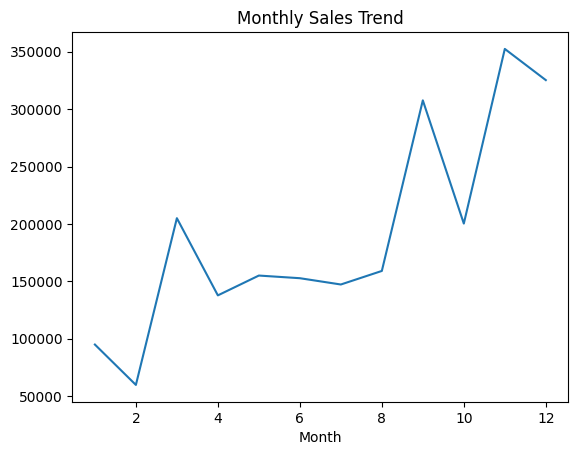

In [9]:
#Monthly Sales Trend
Monthly_Sales=df.groupby('Month')['Sales'].sum()
Monthly_Sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.show()

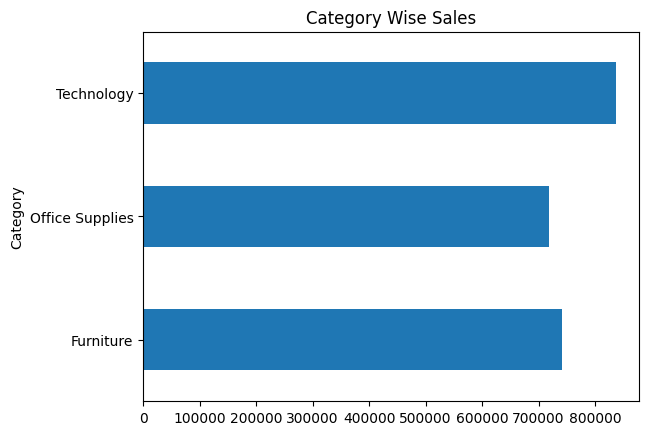

In [10]:
#Category wise Sales
Category_wise_Sales=df.groupby('Category')['Sales'].sum()
Category_wise_Sales.plot(kind='barh')
plt.title('Category Wise Sales')
plt.show()

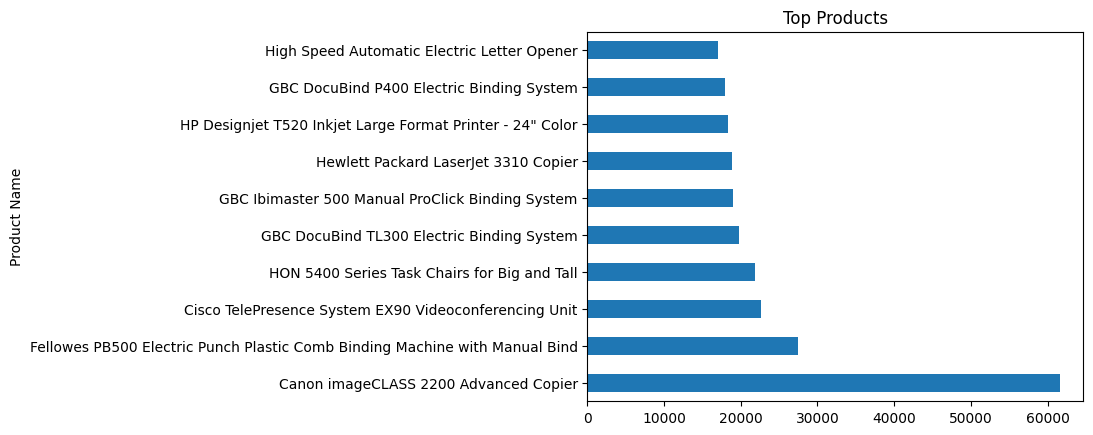

In [11]:
#Top products
top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')
plt.title('Top Products')
plt.show()

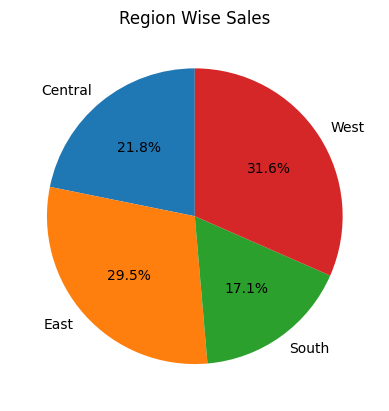

In [12]:
#Region Wise Sales
df.groupby('Region')['Sales'].sum().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title('Region Wise Sales')
plt.show()

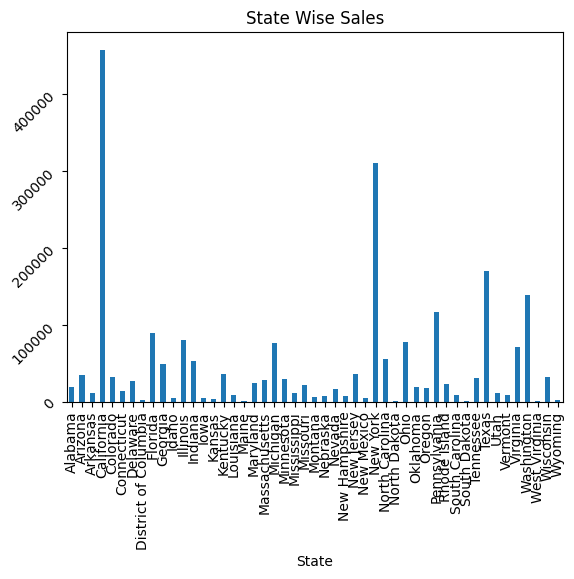

In [13]:
#State wise Sales
df.groupby('State')['Sales'].sum().plot(kind='bar')
plt.title('State Wise Sales')
plt.xticks(rotation=90)
plt.yticks(rotation=45)
plt.show()

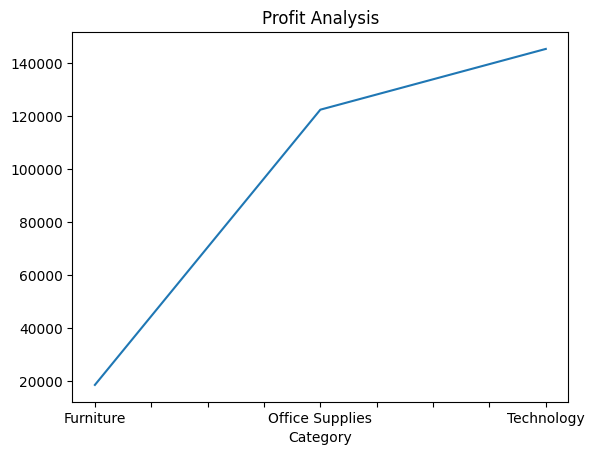

In [14]:
#Profit Analysis
df.groupby('Category')['Profit'].sum().plot(kind='line')
plt.title('Profit Analysis')
plt.show()

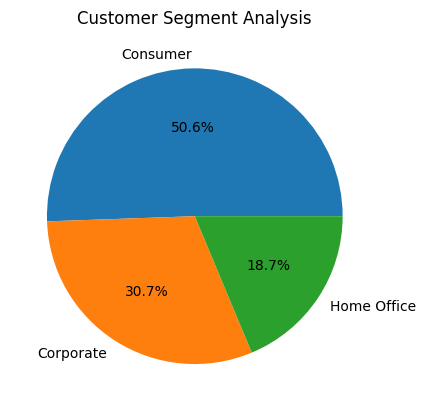

In [15]:
#Costomer Segment Analysis
df.groupby('Segment')['Sales'].sum().plot(kind='pie',autopct='%1.1f%%')
plt.title('Customer Segment Analysis')
plt.show()

5.KPI(Top Summary Metrices)

In [17]:
#Total Sales
total_sales=df['Sales'].sum()
print('Total Sales = ',total_sales)
print('The business generated total Sales of 2.29M, indicating strong overall revenue Performance.')

Total Sales =  2297200.8603
The business generated total Sales of 2.29M, indicating strong overall revenue Performance.


In [18]:
#Total Profit
total_profit=df['Profit'].sum()
print('Total Profit = ',total_profit)
print('The business generated 2.86M of profit which concidered a great amount.')

Total Profit =  286397.0217
The business generated 2.86M of profit which concidered a great amount.


In [ ]:
#Toatal Orders
total_orders=df['Order ID'].nunique()
print('Total Orders = ',total_orders)

Total Orders =  5009


In [ ]:
#Average sale per Order
aver_sale=df['Sales'].mean()
print('Average  Sales Per Order = ',round(aver_sale,2))

Average  Sales Per Order =  229.86


In [ ]:
#Total Quantity
total_quantity=df['Quantity'].sum()
print('Total Quantity Sold = ',total_quantity)

Total Quantity Sold =  37873


6.Profit Margin

In [19]:
profit_margin=(total_profit/total_sales)*100
print('Profit Margin = ',round(profit_margin,2))
print('The business contain  12% of profit Margin.')

Profit Margin =  12.47
The business contain  12% of profit Margin.


7.Business Insights

_'After 8 Months Sales amount Increases.'
_'Technology category generates highest revenue'
_'West Region have more Sales'
_'From Consumers More sales occur'.

8.Recommendations

_'Increasing marketing efforts in low performing regions to boost sales'.
_'Reduce excessive Discounts to improve profit Margin'.